<details>
  <summary><strong>MIT License (クリックで展開)</strong></summary>

  <pre>
MIT License
Copyright (c) 2023 AI Course Notebook Contributors
Repository: https://github.com/arch-inform-kaken-group/ai-course-notebooks

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
  </pre>
</details>


# ニューラルネットワークによる犬猫分類

今回のハンズオンは，画像分類における畳み込み層の効果を体感していただくことが目標です．前半はニューラルネットワーク，後半は畳み込みニューラルネットワークのモデルを作成します．


## 目的：犬と猫の画像を分類すること

今回使用するデータセットは，「Asirra Dataset」「Cats vs Dogs」「Cats and Dogs Dataset」などと呼ばれる犬と猫の画像から構成されるデータセットです．
これまでのハンズオンで使用したMNISTでは，Pythonで分析しやすいよう予め変換された状態でデータセットをダウンロードしていましたが，今回は普通の画像データ（jpeg形式）から読み込みます．



 このデータセットの背景について説明します．「Asirra dataset」の「Asirra」はAnimal Species Image Recognition for Restricting Access（動物種画像認識によるアクセス制限）の略です．Asirraは，外部スパム対策サービスでした（※2014年10月に完全閉鎖済）．

外部スパム対策という言葉だけでは想像しにくいかもしれませんが，いわゆる
```
「私はロボットではありません」
「自転車のタイルをすべて選択してください」「横断歩道の画像をすべて選択してください」
```
というような人間とボットを区別する認証システムの一種だと想像してください．

<small>このようなものを，CAPTCHA（Completely Automated Public Turing test to tell Computers and Humans Apart），または HIP（Human Interactive Proof）と呼びます．</small>



Asirra dataset の特徴は，ホームレスペットの里親探しを目的とした世界最大のサイトである Petfinder.com と提携したことです．このデータセットは，米国の何千もの動物保護施設の人々により手作業で分類され，Microsoft Researchへ提供されました．

<hr>
データセット出典：

[Microsoft] https://www.microsoft.com/en-us/download/details.aspx?id=54765 <br>
[Kaggle] https://www.kaggle.com/c/dogs-vs-cats

## GPU の利用確認とTensorFlowのバージョン確認

In [ ]:
!nvidia-smi

Thu May 30 00:50:52 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   38C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
import tensorflow as tf
import sklearn
import os

print('TensorFlow version:',tf.__version__)
print('scikit-learn version:',sklearn.__version__)

restart_flag = False

if tf.__version__ != '2.15.0':
    !pip install -q --upgrade tensorflow==2.15.0
    print('TensorFlow version:',tf.__version__)
    restart_flag = True

if sklearn.__version__ != '1.2.2':
    !pip install -q --upgrade scikit-learn==1.2.2
    print('scikit-learn version:',sklearn.__version__)
    restart_flag = True

# 以下は，ライブラリのバージョンが変更された場合のみ実行されます．
if restart_flag :
    print("ライブラリバージョンを変更した場合に，自動でランタイムを再起動します．")
    print("colabの場合は【不明な理由でクラッシュした】旨の警告が左下に出てきますが，")
    print("これは無視しても問題ないので次以降のコードセルを実行してください．")
    # ランタイムを再起動させるために，わざとクラッシュさせています．
    get_ipython().kernel.do_shutdown(restart = True)

TensorFlow version: 2.15.0
scikit-learn version: 1.2.2


### 外部ライブラリのインストール

https://pypi.org/project/split-folders/<br>

In [ ]:
!pip install split-folders # データセット分割用の外部ライブラリ

### ライブラリインポート

In [ ]:
import os # os：標準ライブラリ，OS依存の処理（環境変数やフォルダ作成など）を扱う
import datetime # datetime：標準ライブラリ，日付関連データを扱う
import random # random：標準ライブラリ，擬似乱数発生器
import numpy as np # numpy：数値計算用ライブラリの一つ
import pandas as pd # pandas：表計算用ライブラリの一つ
from IPython.display import display # Colabなどで一部のデータをprint()よりも綺麗に出力できる関数
import matplotlib.pylab as plt # matplotlib：グラフ描画用ライブラリの一つ
import seaborn as sns # seaborn：グラフ描画用ライブラリの一つ
from sklearn.metrics import classification_report # 機械学習ライブラリの一つ（今回はPrecision,Recall,F1-Scoreの出力時に使用するのみ）
# tensorboard：深層学習ライブラリTensorFlowのダッシュボード出力用設定
%load_ext tensorboard
import tensorflow as tf # TensorFlow：深層学習ライブラリ一つ

import shutil #shutil:標準ライブラリ，ファイル群を操作する
import splitfolders # split-folders：画像データをtrain, validation, test フォルダへ分割する外部ライブラリ
import glob # glob:パスを扱う標準ライブラリ
import imghdr # imghdr;標準ライブラリ，画像ファイルの整合性確認用（※将来のPythonバージョンでは削除されるライブラリです．），

from PIL import ImageFile #PIL 画像処理用の外部ライブラリ（警告抑制用に使用）
ImageFile.LOAD_TRUNCATED_IMAGES = True #警告抑制用（おまじないだと思ってください）

### 擬似乱数発生器のrandom seed 固定

* 下記プログラム中で生成・使用される擬似乱数列を固定します．
* random seed は擬似乱数列を生成する時の初期化に使われる数値です．
* 明示的に指定しない場合は，時刻などで初期化されます．
* 今回は再現性を確保する（誰がいつ実行しても同じ擬似乱数列を生成させる）ために random seed を固定します．

<small> ※ colab では割り当てられるCPU/GPUやライブラリバージョンの違いにより，完全再現は難しい場合もあります.</small>

In [ ]:
def set_seed(seed = 123):
    # hash seed の固定
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Python外部ライブラリ：TensorFlow の ニューラルネットワークを決定論的に動作させる
    os.environ['TF_DETERMINISTIC_OPS'] = 'true'
    # Python外部ライブラリ：TensorFlow の ニューラルネットワークを決定論的に動作させる
    os.environ['TF_CUDNN_DETERMINISTIC'] = 'true'
    # Python標準ライブラリ：random の seed固定
    random.seed(seed)
    # Python外部ライブラリ：Numpy の seed固定
    np.random.seed(seed)
    # Python外部ライブラリ：TensorFlow の seed固定
    tf.random.set_seed(seed)

set_seed(42)

## データセットの取得


In [ ]:
!wget https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

# zip ファイルの展開
!unzip -q kagglecatsanddogs_5340.zip

!ls -lh /content/PetImages

--2024-05-30 00:52:39--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.44.78.15, 2600:1402:1400:f84::317f, 2600:1402:1400:f85::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.44.78.15|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘kagglecatsanddogs_5340.zip’

kagglecatsanddogs_5 100%[===================>] 786.67M   124MB/s    in 10s     

2024-05-30 00:52:49 (78.4 MB/s) - ‘kagglecatsanddogs_5340.zip’ saved [824887076/824887076]

total 548K
drwxr-xr-x 2 root root 272K Feb 10  2017 Cat
drwxr-xr-x 2 root root 272K Feb 10  2017 Dog


## 画像データの整合性確認
実はこのデータセットは，少々「汚い」データセットです．幾つか挙げると，
1. 犬と猫以外の動物や人間も写っている画像がある．
2. 画像のサイズや縦横比が不統一である．
3. **拡張子と画像の形式が一致していない画像がある．**

などです．この画像データセットの拡張子**だけ**は，全て「.jpg」（jpeg形式）となっていますが，内部のデータ形式はpng形式だったりbmp形式だったり，別の形式の画像が混入しています．

<small>前回（6回目）のハンズオン資料の補足に記載しましたが，ファイル名の変更などで拡張子を変更するとこのようなことになります．拡張子だけ変更しても，内部のデータ形式は変わりません．皆さんはやらないように！<small>

今回のPythonプログラムでは，このようなデータ形式と拡張子が一致していない画像ファイルがあると正常に動作しないため，事前に整合性を確認して削除します．




In [ ]:
# 画像データの整合性確認用
dirs = ["/content/PetImages/Cat", "/content/PetImages/Dog",]

for dir_name in dirs:
    # 画像のパスリストを作成し，全画像を確認する
    for file in glob.glob(dir_name + "/*.jpg"):
        if imghdr.what(file) != 'jpeg':
            # 拡張子だけはjpgだけれども，実際にはjpeg形式ではない画像ファイル
            print(f"画像ファイルのパス：{file}，本当のデータ形式：{imghdr.what(file)}", )
            # そのファイルを削除する
            os.remove(file)

画像ファイルのパス：/content/PetImages/Cat/11729.jpg，本当のデータ形式：bmp
画像ファイルのパス：/content/PetImages/Cat/4322.jpg，本当のデータ形式：bmp
画像ファイルのパス：/content/PetImages/Cat/7845.jpg，本当のデータ形式：bmp
画像ファイルのパス：/content/PetImages/Cat/11091.jpg，本当のデータ形式：None
画像ファイルのパス：/content/PetImages/Cat/8553.jpg，本当のデータ形式：bmp
画像ファイルのパス：/content/PetImages/Cat/1267.jpg，本当のデータ形式：bmp
画像ファイルのパス：/content/PetImages/Cat/9328.jpg，本当のデータ形式：bmp
画像ファイルのパス：/content/PetImages/Cat/2569.jpg，本当のデータ形式：bmp
画像ファイルのパス：/content/PetImages/Cat/5089.jpg，本当のデータ形式：None
画像ファイルのパス：/content/PetImages/Cat/6376.jpg，本当のデータ形式：bmp
画像ファイルのパス：/content/PetImages/Cat/7245.jpg，本当のデータ形式：None
画像ファイルのパス：/content/PetImages/Cat/9778.jpg，本当のデータ形式：gif
画像ファイルのパス：/content/PetImages/Cat/1937.jpg，本当のデータ形式：bmp
画像ファイルのパス：/content/PetImages/Cat/4334.jpg，本当のデータ形式：bmp
画像ファイルのパス：/content/PetImages/Cat/2663.jpg，本当のデータ形式：gif
画像ファイルのパス：/content/PetImages/Cat/9208.jpg，本当のデータ形式：bmp
画像ファイルのパス：/content/PetImages/Cat/8157.jpg，本当のデータ形式：None
画像ファイルのパス：/content/PetImages/Cat/8415.jpg，本当のデータ形式：bmp
画像ファ

In [ ]:
# 削除後の画像枚数
print('Cat images '+ str( len(glob.glob("/content/PetImages/Cat/*.jpg"))) )
print('Dog images '+ str( len(glob.glob("/content/PetImages/Dog/*.jpg"))) )

Cat images 12385
Dog images 12349


時間短縮のため，各1000枚ずつ画像を使用します．

In [ ]:
os.makedirs('sample1000/Dog', exist_ok = True)
os.makedirs('sample1000/Cat', exist_ok = True)


for image in random.sample(glob.glob("/content/PetImages/Cat/*.jpg"), k = 1000):
    new_path = 'sample1000/Cat/' + os.path.basename(image)
    shutil.move(image, new_path)

for image in random.sample(glob.glob("/content/PetImages/Dog/*.jpg"), k = 1000):
    new_path = 'sample1000/Dog/' + os.path.basename(image)
    shutil.move(image, new_path)

## 画像データセットの分割

In [ ]:
splitfolders.ratio('/content/sample1000', output = "dataset", seed = 1337, ratio = (0.6, 0.2, 0.2))

!ls -lh /content/dataset

Copying files: 2000 files [00:00, 6519.81 files/s]


total 12K
drwxr-xr-x 4 root root 4.0K May 30 00:56 test
drwxr-xr-x 4 root root 4.0K May 30 00:56 train
drwxr-xr-x 4 root root 4.0K May 30 00:56 val


In [ ]:
# train データセットの画像枚数
len_train = len(glob.glob("/content/dataset/train/*/*.jpg"))

# validation データセットの画像枚数
len_valid = len(glob.glob("/content/dataset/val/*/*.jpg"))

# test データセットの画像枚数
len_test = len(glob.glob("/content/dataset/test/*/*.jpg"))

print('train データセットの画像枚数：'+ str(len_train))
print('validation データセットの画像枚数：'+ str(len_valid))
print('test データセットの画像枚数：'+ str(len_test))


train データセットの画像枚数：1200
validation データセットの画像枚数：400
test データセットの画像枚数：400



train/val/test の説明とディレクトリ階層の説明

```
dataset ------ train ------ Cat----猫画像ファイル
          |             |
          |             --- Dog----犬画像ファイル
          |
          ---- val ------ Cat----猫画像ファイル
          |             |
          |             --- Dog----犬画像ファイル
          |
          ---- test ------ Cat----猫画像ファイル
                        |
                        --- Dog----犬画像ファイル          
```

## 入力データの生成

画像ファイルが格納されたディレクトリからデータを読み込んで，学習モデルに入力するための準備を行います．
今回はクラス名を指定していませんので，デフォルトの設定によりディレクトリ名順 (`['cat', 'dog']`) にラベルが付与されます．

In [ ]:
train_dir = './dataset/train/'
validation_dir = './dataset/val/'
test_dir = './dataset/test/'

image_size = (128, 128)  # 入力データの縦横のサイズ．画像ファイルはこのサイズに自動的にリサイズされる．
batch_size = 128  # バッチサイズ．1度に取り込む入力データの数．

image_data_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1/255.0)
# 画像データはRGBの値が0から255までの値になっているので，
# rescaleして値を0から1までの範囲にすることで，学習の収束を早くする．

train_generator = image_data_generator.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size
)
train_dataset = tf.data.Dataset.from_generator(
    lambda:train_generator,
    output_signature=(
        tf.TensorSpec(shape = (None, 128, 128, 3), dtype = tf.float32),
        tf.TensorSpec(shape = (None, 2), dtype = tf.float32),
    ),
)

valid_generator = image_data_generator.flow_from_directory(
    validation_dir,
    target_size=image_size,
    batch_size=batch_size
)
valid_dataset = tf.data.Dataset.from_generator(
    lambda:valid_generator,
    output_signature=(
        tf.TensorSpec(shape = (None, 128, 128, 3), dtype = tf.float32),
        tf.TensorSpec(shape = (None, 2), dtype = tf.float32),
    )
)


test_generator = image_data_generator.flow_from_directory(
    test_dir,
    target_size = image_size,
    batch_size = batch_size
)
test_dataset = tf.data.Dataset.from_generator(
    lambda:test_generator,
    output_signature=(
        tf.TensorSpec(shape = (None, 128, 128, 3), dtype = tf.float32),
        tf.TensorSpec(shape = (None, 2), dtype = tf.float32),
    )
)

Found 1200 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Found 400 images belonging to 2 classes.


(128, 128, 128, 3)
(128, 2)


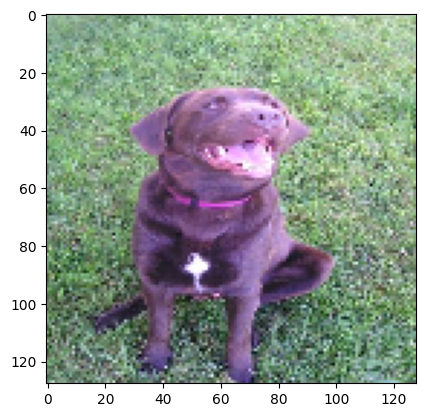

ラベル： dog
------------------------------------------------------------



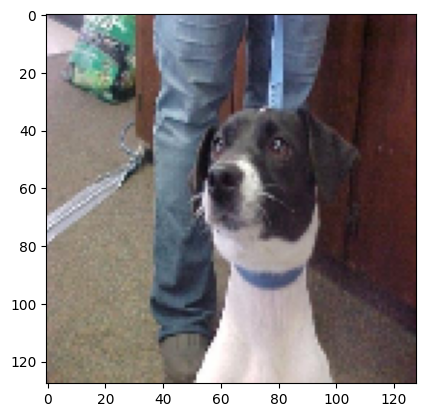

ラベル： dog
------------------------------------------------------------



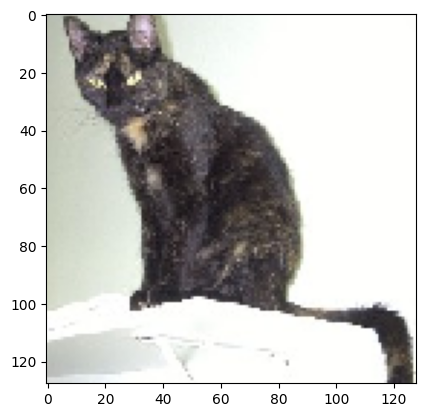

ラベル： cat
------------------------------------------------------------



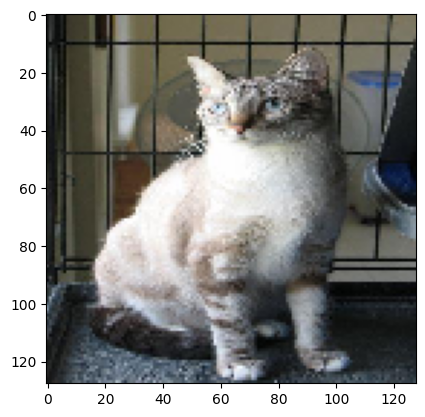

ラベル： cat
------------------------------------------------------------



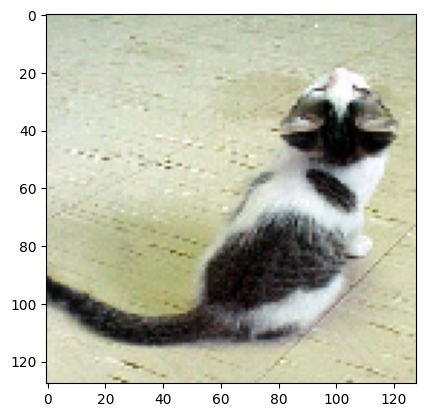

ラベル： cat
------------------------------------------------------------



In [ ]:
class_names = ['cat', 'dog']

# 1バッチ分を取得
for images, labels in train_dataset.take(1):

    #しかし，今回はバッチサイズが128と
    # プロットするには多いので
    print(images.shape)
    print(labels.shape)

    # 先頭の5枚のみプロットします．
    for i in range(5):
        plt.imshow(images[i])
        plt.show()
        print('ラベル：', class_names[np.argmax(labels[i])])
        print(''.join(['-' for _ in range(60)]), end = '\n\n')


## ニューラルネットワークモデルの構築

In [ ]:
# input層（入力層）：(128 x 128 x 3チャンネル)
inputs_images = tf.keras.layers.Input( shape = (128, 128, 3), name = 'input' )


# Flatten層（平坦化層）
# (None, 128, 128, 3) -> (None, 49152)
x = tf.keras.layers.Flatten()(inputs_images)

# Dense層（全結合層）
# (None, 49152) -> (None, 512)
x = tf.keras.layers.Dense(units = 512, kernel_initializer='he_normal', activation = 'relu', name = 'fc_1')(x)
# (None, 512) -> (None, 256)
x = tf.keras.layers.Dense(units = 256, kernel_initializer='he_normal', activation = 'relu', name = 'fc_2')(x)
# (None, 256) -> (None, 128)
x = tf.keras.layers.Dense(units = 128, kernel_initializer='he_normal', activation = 'relu', name = 'fc_3')(x)
# (None, 128) -> (None, 2)
outputs = tf.keras.layers.Dense(units = 2, kernel_initializer='he_normal', activation = 'softmax')(x)

# モデルを定義
model = tf.keras.Model(inputs = inputs_images, outputs = outputs, name = 'cats_vs_dogs_model')


# モデルのコンパイル（最適化アルゴリズム・損失関数・評価指標などを設定）
# 損失関数は2.6章で学びます．
model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 1.0e-3), #最適化アルゴリズム
              loss = 'categorical_crossentropy', # 損失関数
              metrics = ['accuracy'] #監視用の指標（モデルの訓練そのものには影響しない）
              )


# モデルの構造をテキストで出力
model.summary()

Model: "cats_vs_dogs_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 128, 128, 3)]     0         
                                                                 
 flatten (Flatten)           (None, 49152)             0         
                                                                 
 fc_1 (Dense)                (None, 512)               25166336  
                                                                 
 fc_2 (Dense)                (None, 256)               131328    
                                                                 
 fc_3 (Dense)                (None, 128)               32896     
                                                                 
 dense (Dense)               (None, 2)                 258       
                                                                 
Total params: 25330818 (96.63 MB)
Trainable para

## モデルの訓練

In [ ]:
# 訓練中のログファイルを作成する準備
callbacks = []
callbacks.append(tf.keras.callbacks.CSVLogger('training_log.csv'))

# .TensorBoardを作成する準備
os.makedirs('/contents/logs/fit/', exist_ok = True)# フォルダ作成
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir = log_dir, histogram_freq = 1)

callbacks.append(tensorboard_callback)

# モデルの訓練（GPUで3分ほど）
history = model.fit(train_dataset.shuffle(buffer_size=10),
                    batch_size = batch_size,
                    steps_per_epoch = len_train // batch_size,
                    epochs = 20,
                    verbose = 1,
                    validation_data = valid_dataset,
                    validation_steps = len_valid // batch_size,
                    callbacks = callbacks
                    )


Epoch 1/20
9/9 [==============================] - 16s 1s/step - loss: 14.9635 - accuracy: 0.5140 - val_loss: 17.6537 - val_accuracy: 0.5000
Epoch 2/20
9/9 [==============================] - 8s 1s/step - loss: 13.9798 - accuracy: 0.5009 - val_loss: 1.2456 - val_accuracy: 0.5331
Epoch 3/20
9/9 [==============================] - 10s 1s/step - loss: 3.1369 - accuracy: 0.5139 - val_loss: 10.8488 - val_accuracy: 0.5037
Epoch 4/20
9/9 [==============================] - 10s 1s/step - loss: 11.1100 - accuracy: 0.4870 - val_loss: 13.1834 - val_accuracy: 0.4816
Epoch 5/20
9/9 [==============================] - 9s 1s/step - loss: 12.8336 - accuracy: 0.5192 - val_loss: 18.1375 - val_accuracy: 0.5026
Epoch 6/20
9/9 [==============================] - 9s 1s/step - loss: 10.0911 - accuracy: 0.5171 - val_loss: 7.9172 - val_accuracy: 0.5074
Epoch 7/20
9/9 [==============================] - 10s 1s/step - loss: 5.2967 - accuracy: 0.5113 - val_loss: 1.0913 - val_accuracy: 0.6103
Epoch 8/20
9/9 [============

## モデルの評価

### 訓練済モデルによる推論

In [ ]:
train_loss, train_acc = model.evaluate(train_dataset, steps = (len_train//batch_size) + 1, verbose = 1)
print("loss (train): {:.4}".format(train_loss))
print("accuracy (train): {:.4}".format(train_acc))

print()

valid_loss, valid_acc = model.evaluate(valid_dataset, steps = (len_valid//batch_size) + 1, verbose = 1)
print("loss (valid): {:.4}".format(valid_loss))
print("accuracy (valid): {:.4}".format(valid_acc))

print()

test_loss, test_acc = model.evaluate(test_dataset, steps = (len_test//batch_size) + 1, verbose = 1)
print("loss (test): {:.4}".format(test_loss))
print("accuracy (test): {:.4}".format(test_acc))

10/10 [==============================] - 2s 192ms/step - loss: 0.5229 - accuracy: 0.7450
loss (train): 0.5229
accuracy (train): 0.745

4/4 [==============================] - 1s 140ms/step - loss: 0.6714 - accuracy: 0.6025
loss (valid): 0.6714
accuracy (valid): 0.6025

4/4 [==============================] - 1s 151ms/step - loss: 0.6787 - accuracy: 0.6050
loss (test): 0.6787
accuracy (test): 0.605


### ログの表示

In [ ]:
log_df = pd.read_csv('training_log.csv')
display(log_df.head(10))

,epoch,accuracy,loss,val_accuracy,val_loss
0,0,0.513993,14.963481,0.500000,17.653677
1,1,0.500933,13.979805,0.533088,1.245606
2,2,0.513889,3.136880,0.503676,10.848751
3,3,0.486979,11.110023,0.481618,13.183389
4,4,0.519153,12.833595,0.502604,18.137506
5,5,0.517137,10.091059,0.507353,7.917155
6,6,0.511285,5.296674,0.610294,1.091253
7,7,0.525187,1.793749,0.580882,1.018318
8,8,0.626866,0.816802,0.549479,0.940621
9,9,0.567164,1.282132,0.511029,1.968355


### 損失関数と評価指標の推移

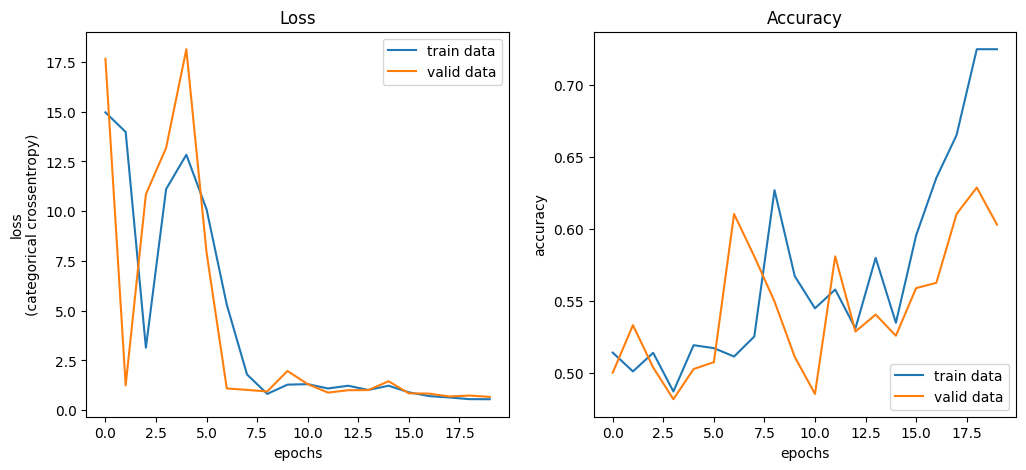

In [ ]:
epochs = log_df["epoch"].values
train_acc = log_df["accuracy"].values
train_loss = log_df["loss"].values
valid_acc = log_df["val_accuracy"].values
valid_loss = log_df["val_loss"].values

fig, axes = plt.subplots(1,2, figsize = (12,5))

axes[0].plot(epochs, train_loss, label = "train data")
axes[0].plot(epochs, valid_loss, label = "valid data")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss\n(categorical crossentropy)")
axes[0].legend(loc="upper right")
axes[0].set_title("Loss")

axes[1].plot(epochs, train_acc, label = "train data")
axes[1].plot(epochs, valid_acc, label = "valid data")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("accuracy")
axes[1].legend(loc = "lower right")
axes[1].set_title("Accuracy")

plt.show()

`train`の損失や正答率は，学習を重ねる毎に少しずつ改善されていることがうかがえます．

`validation`の損失や正答率を見ると，損失は値が収束していますが，正答率は大きくぶれており，あまり学習できていないことがうかがえます．

結果を混同行列を使って確認してみましょう．混同行列とは以下のような表になっています．

|↓教師データ ／ 出力結果→| 0: 猫 | 1: 犬 |
|:---|:---|:---|
|0: 猫|正しく猫と判定した|猫なのに，犬と判定した|
|1: 犬|犬なのに，猫と判定した|正しく犬と判定した|

この中では対角線上にある，「正しく猫と判定した」と「正しく犬と判定した」に該当すると正答となります．

### 混同行列の描画

1/1 [==============================] - 0s 73ms/step


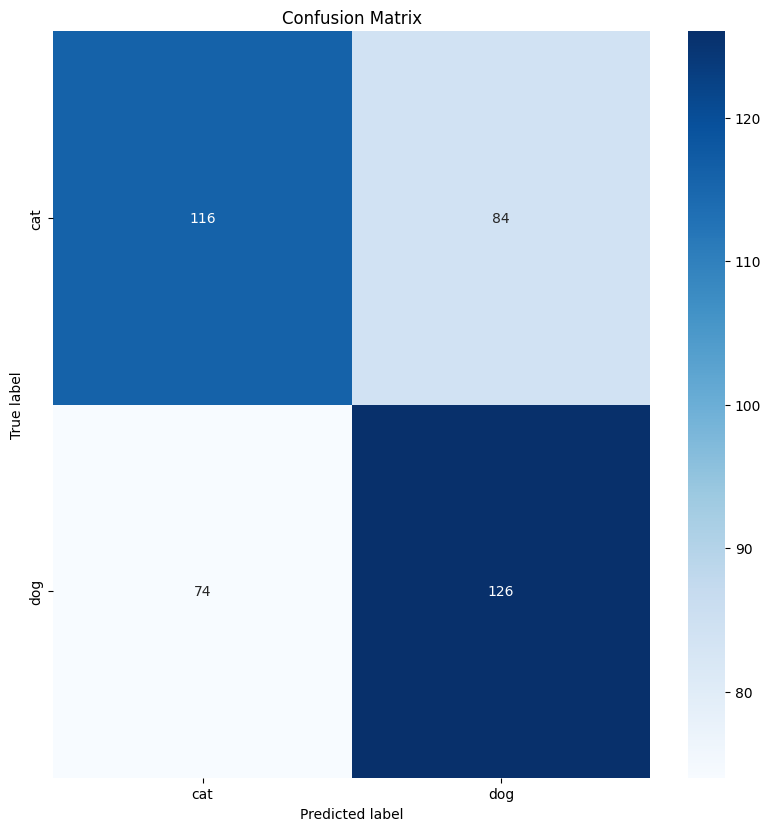

In [ ]:
class_names = ['cat', 'dog']

con_matrix = np.zeros((2,2))

for x, y in test_dataset.take( (len_test//batch_size) + 1 ):
    y_pred = np.argmax(model.predict(x), axis = -1)
    y_true = np.argmax(y, axis=1)
    con_matrix += tf.math.confusion_matrix(labels = y_true, predictions = y_pred).numpy()

con_mat_df = pd.DataFrame(con_matrix,
                     index = class_names,
                     columns = class_names
                     )

figure = plt.figure(figsize=(8, 8))
sns.heatmap(con_mat_df, annot = True, cmap = plt.cm.Blues, fmt = 'g')
plt.tight_layout()
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

(128, 128, 128, 3)
(128, 2)


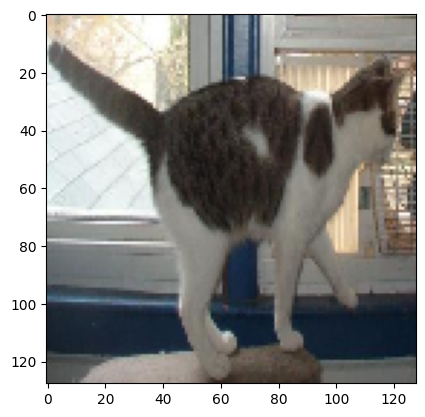

推定： cat
正解： cat
------------------------------------------------------------



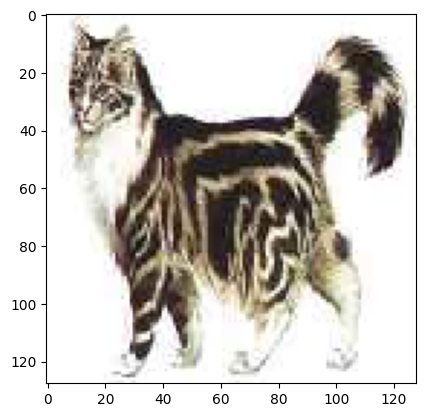

推定： dog
正解： cat
------------------------------------------------------------



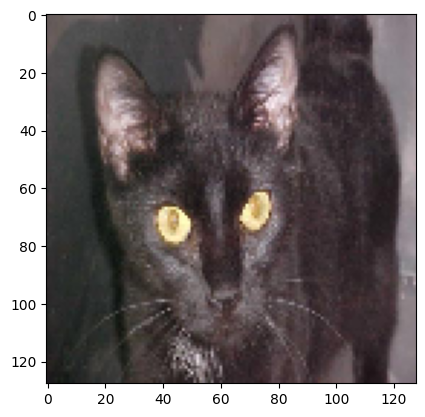

推定： dog
正解： cat
------------------------------------------------------------



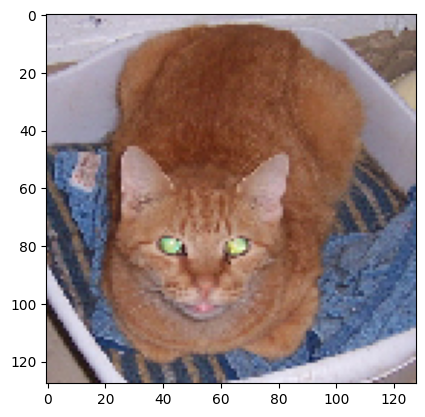

推定： cat
正解： cat
------------------------------------------------------------



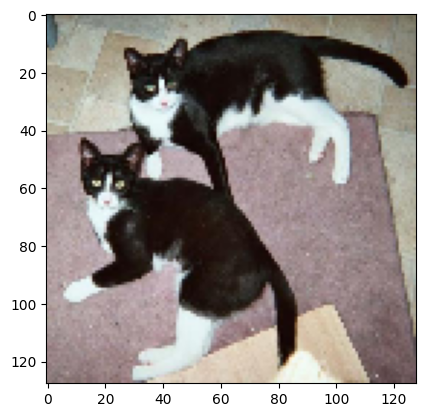

推定： cat
正解： cat
------------------------------------------------------------



In [ ]:
code_to_class = {0: 'cat', 1: 'dog'}

# 1バッチ分を取得
for images, labels in train_dataset.take(1):

    y_true = np.argmax( labels, axis = 1 )
    y_prob = model.predict_on_batch( images )
    y_pred = np.argmax( y_prob, axis = 1 )

    #しかし，今回はバッチサイズが128と
    # プロットするには多いので
    print(images.shape)
    print(labels.shape)

    # 先頭の5枚のみプロットします．
    for i in range(5):
        plt.imshow(images[i])
        plt.show()
        print('推定：', code_to_class[y_pred[i]])
        print('正解：', code_to_class[y_true[i]])
        print(''.join(['-' for _ in range(60)]), end = '\n\n')

# 畳み込みニューラルネットワークによる犬猫分類

全結合層のみのネットワークは精度がいいとは言えませんね． そこで，先ほどのモデルを改良して，今度は畳込みニューラルネットワークを構築します．

### 入力データの生成

先ほどと同じです．

In [ ]:
train_dir = './dataset/train/'
validation_dir = './dataset/val/'
test_dir = './dataset/test/'

image_size = (128, 128)  # 入力データの縦横のサイズ．画像ファイルはこのサイズに自動的にリサイズされる．
batch_size = 128  # バッチサイズ．1度に取り込む入力データの数．

image_data_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale = 1/255.0)
# 画像データはRGBの値が0から255までの値になっているので，
# rescaleして値を0から1までの範囲にすることで，学習の収束を早くする．


train_generator = image_data_generator.flow_from_directory(
    train_dir,
    target_size = image_size,
    batch_size = batch_size
)
train_dataset = tf.data.Dataset.from_generator(
    lambda:train_generator,
    output_signature=(
        tf.TensorSpec(shape = (None, 128, 128, 3), dtype = tf.float32),
        tf.TensorSpec(shape = (None, 2), dtype = tf.float32),
    ),
)

valid_generator = image_data_generator.flow_from_directory(
    validation_dir,
    target_size = image_size,
    batch_size = batch_size
)
valid_dataset = tf.data.Dataset.from_generator(
    lambda:valid_generator,
    output_signature = (
        tf.TensorSpec(shape = (None, 128, 128, 3), dtype = tf.float32),
        tf.TensorSpec(shape = (None, 2), dtype = tf.float32),
    )
)


test_generator = image_data_generator.flow_from_directory(
    test_dir,
    target_size = image_size,
    batch_size = batch_size
)
test_dataset = tf.data.Dataset.from_generator(
    lambda:test_generator,
    output_signature = (
        tf.TensorSpec(shape = (None, 128, 128, 3), dtype = tf.float32),
        tf.TensorSpec(shape = (None, 2), dtype = tf.float32),
    )
)

Found 1200 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Found 400 images belonging to 2 classes.


### 畳み込みニューラルネットワークモデルの構築


以下のように構築してみます．

In [ ]:
# input層（入力層）：(128 x 128 x 3 チャンネル)
inputs_images = tf.keras.layers.Input(shape = (128, 128, 3), name = 'input')

# 3x3 の 畳み込みカーネル(フィルタ) が32枚
x = tf.keras.layers.Conv2D(filters = 32, strides = (1, 1), kernel_size = (3, 3),\
                           kernel_initializer='he_normal', activation = 'relu', name = 'conv_1')(inputs_images)
# 2x2 の Max Pooling
x = tf.keras.layers.MaxPooling2D(pool_size = (2, 2), strides = (2, 2), name = 'pool_1')(x)
# 3x3 の 畳み込みカーネル(フィルタ) が64枚
x = tf.keras.layers.Conv2D(filters = 64, strides = (1, 1), kernel_size = (3, 3),\
                           kernel_initializer='he_normal', activation = 'relu', name = 'conv_2')(x)
# 2x2 の Max Pooling
x = tf.keras.layers.MaxPooling2D(pool_size = (2, 2), strides = (2, 2), name = 'pool_2')(x)


# Flatten層（平坦化層）
# (None, 30, 30, 64) -> (None,  57600)
x = tf.keras.layers.Flatten()(x)

# Dense層（全結合層）
# (None, 57600) -> (None, 512)
x = tf.keras.layers.Dense(units = 512, kernel_initializer='he_normal', activation = 'relu', name = 'fc_1')(x)
# (None, 512) -> (None, 256)
x = tf.keras.layers.Dense(units = 256, kernel_initializer='he_normal', activation = 'relu', name = 'fc_2')(x)
# (None, 256) -> (None, 128)
x = tf.keras.layers.Dense(units = 128, kernel_initializer='he_normal', activation = 'relu', name = 'fc_3')(x)
# (None, 128) -> (None, 2)
outputs = tf.keras.layers.Dense(units = 2, kernel_initializer='he_normal', activation = 'softmax')(x)

# モデルを定義
model = tf.keras.Model(inputs = inputs_images, outputs = outputs, name = 'cats_vs_dogs_cnn_model')


# モデルのコンパイル（最適化アルゴリズム・損失関数・評価指標などを設定）
# 損失関数は2.6章で学びます．
model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 1.0e-3), #最適化アルゴリズム
              loss = 'categorical_crossentropy', # 損失関数
              metrics = ['accuracy'] #監視用の指標（モデルの訓練そのものには影響しない）
              )


# モデルの構造をテキストで出力
model.summary()

Model: "cats_vs_dogs_cnn_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 128, 128, 3)]     0         
                                                                 
 conv_1 (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 pool_1 (MaxPooling2D)       (None, 63, 63, 32)        0         
                                                                 
 conv_2 (Conv2D)             (None, 61, 61, 64)        18496     
                                                                 
 pool_2 (MaxPooling2D)       (None, 30, 30, 64)        0         
                                                                 
 flatten_1 (Flatten)         (None, 57600)             0         
                                                                 
 fc_1 (Dense)                (None, 512)    

## モデルの訓練

In [ ]:
# 訓練中のログファイルを作成する準備
callbacks = []
callbacks.append(tf.keras.callbacks.CSVLogger('training_log_cnn.csv'))

# .TensorBoardを作成する準備
os.makedirs('/contents/logs_cnn/fit/', exist_ok=True)# フォルダ作成
log_dir = "logs_cnn/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir = log_dir, histogram_freq = 1)

callbacks.append(tensorboard_callback)

# モデルの訓練（GPUで5分ほど）
history = model.fit(train_dataset.shuffle(buffer_size=10),
                    batch_size = batch_size,
                    steps_per_epoch = len_train // batch_size,
                    epochs = 20,
                    verbose = 1,
                    validation_data = valid_dataset,
                    validation_steps = len_valid // batch_size,
                    callbacks = callbacks
                    )

Epoch 1/20
9/9 [==============================] - 16s 1s/step - loss: 19.6455 - accuracy: 0.5182 - val_loss: 1.4162 - val_accuracy: 0.4974
Epoch 2/20
9/9 [==============================] - 12s 1s/step - loss: 1.0438 - accuracy: 0.4929 - val_loss: 0.6848 - val_accuracy: 0.5515
Epoch 3/20
9/9 [==============================] - 12s 1s/step - loss: 0.6507 - accuracy: 0.6091 - val_loss: 0.6765 - val_accuracy: 0.5588
Epoch 4/20
9/9 [==============================] - 11s 1s/step - loss: 0.7006 - accuracy: 0.5677 - val_loss: 0.7881 - val_accuracy: 0.5147
Epoch 5/20
9/9 [==============================] - 12s 1s/step - loss: 0.6083 - accuracy: 0.6649 - val_loss: 0.6933 - val_accuracy: 0.5547
Epoch 6/20
9/9 [==============================] - 11s 1s/step - loss: 0.5251 - accuracy: 0.7276 - val_loss: 0.5908 - val_accuracy: 0.6581
Epoch 7/20
9/9 [==============================] - 10s 1s/step - loss: 0.4413 - accuracy: 0.7994 - val_loss: 0.6583 - val_accuracy: 0.6213
Epoch 8/20
9/9 [=================

## モデルの評価

### 訓練済モデルによる推論

In [ ]:
train_loss, train_acc = model.evaluate(train_dataset, steps = (len_train // batch_size) + 1, verbose = 1)
print("loss (train): {:.4}".format(train_loss))
print("accuracy (train): {:.4}".format(train_acc))

print()

valid_loss, valid_acc = model.evaluate(valid_dataset, steps = (len_valid // batch_size) + 1, verbose = 1)
print("loss (valid): {:.4}".format(valid_loss))
print("accuracy (valid): {:.4}".format(valid_acc))

print()

test_loss, test_acc = model.evaluate(test_dataset, steps = (len_test // batch_size) + 1, verbose = 1)
print("loss (test): {:.4}".format(test_loss))
print("accuracy (test): {:.4}".format(test_acc))

10/10 [==============================] - 2s 214ms/step - loss: 0.0039 - accuracy: 1.0000
loss (train): 0.003878
accuracy (train): 1.0

4/4 [==============================] - 1s 156ms/step - loss: 1.7239 - accuracy: 0.6525
loss (valid): 1.724
accuracy (valid): 0.6525

4/4 [==============================] - 1s 160ms/step - loss: 1.6284 - accuracy: 0.6600
loss (test): 1.628
accuracy (test): 0.66


### ログの表示

In [ ]:
log_df = pd.read_csv('training_log_cnn.csv')
display(log_df.head(10))

,epoch,accuracy,loss,val_accuracy,val_loss
0,0,0.518229,19.645477,0.497396,1.416164
1,1,0.492944,1.043769,0.551471,0.684809
2,2,0.609142,0.650708,0.558824,0.676533
3,3,0.567708,0.700619,0.514706,0.788113
4,4,0.664931,0.608325,0.554688,0.693259
5,5,0.727612,0.525094,0.658088,0.590777
6,6,0.799395,0.441340,0.621324,0.658347
7,7,0.846082,0.353399,0.643382,0.679404
8,8,0.888060,0.293710,0.656250,0.752160
9,9,0.926215,0.232731,0.643382,0.801676


### 損失関数と評価指標の推移

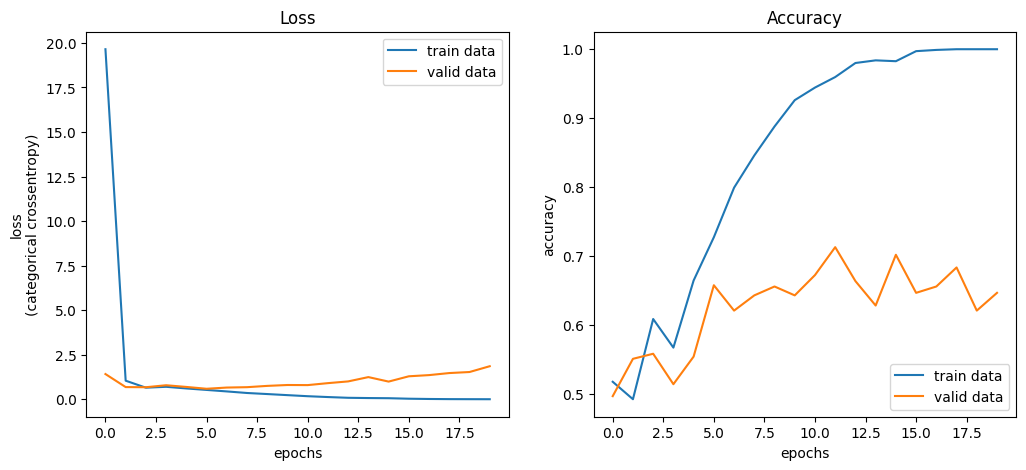

In [ ]:
epochs = log_df["epoch"].values
train_acc = log_df["accuracy"].values
train_loss = log_df["loss"].values
valid_acc = log_df["val_accuracy"].values
valid_loss = log_df["val_loss"].values

fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].plot(epochs, train_loss, label="train data")
axes[0].plot(epochs, valid_loss, label="valid data")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss\n(categorical crossentropy)")
axes[0].legend(loc="upper right")
axes[0].set_title("Loss")

axes[1].plot(epochs, train_acc, label="train data")
axes[1].plot(epochs, valid_acc, label="valid data")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("accuracy")
axes[1].legend(loc="lower right")
axes[1].set_title("Accuracy")

plt.show()

先ほどは大きくぶれていた正解率が改善されていることが分かります．一方で，明らかに過学習が始まっていることもわかります．

### 混同行列の描画

1/1 [==============================] - 0s 99ms/step


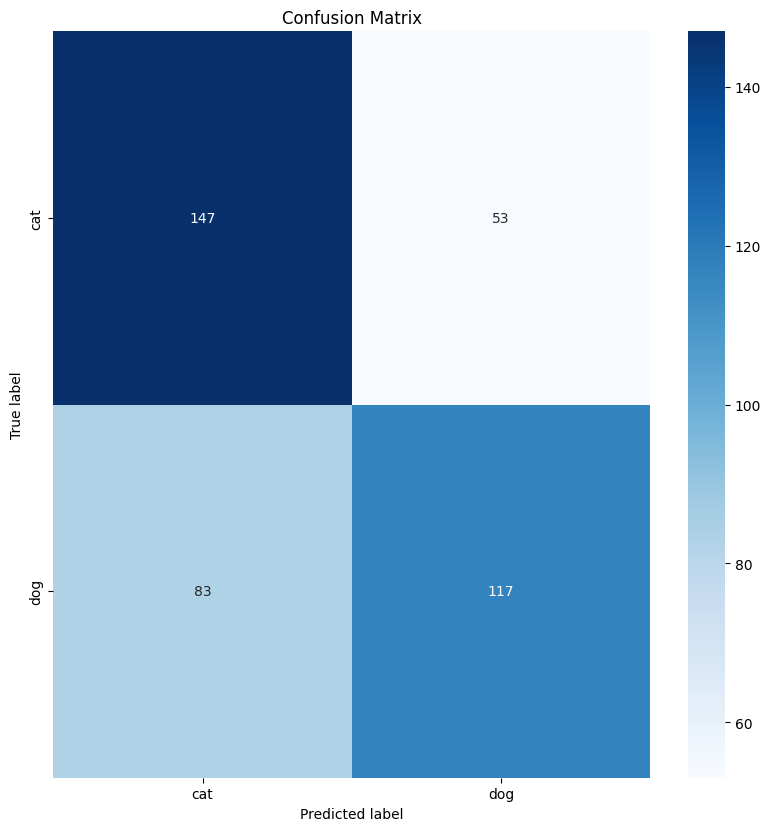

In [ ]:
class_names = ['cat', 'dog']

con_matrix = np.zeros((2,2))

for x, y in test_dataset.take( (len_test//batch_size) + 1 ):
    y_pred = np.argmax(model.predict(x), axis = -1)
    y_true = np.argmax(y, axis = 1)
    con_matrix += tf.math.confusion_matrix(labels = y_true, predictions = y_pred).numpy()

con_mat_df = pd.DataFrame(con_matrix,
                     index = class_names,
                     columns = class_names
                     )

figure = plt.figure(figsize = (8, 8))
sns.heatmap(con_mat_df, annot = True, cmap = plt.cm.Blues, fmt = 'g')
plt.tight_layout()
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

今回は，畳込みニューラルネットワークを使った方がうまく分類できるようです．

(48, 128, 128, 3)
(48, 2)


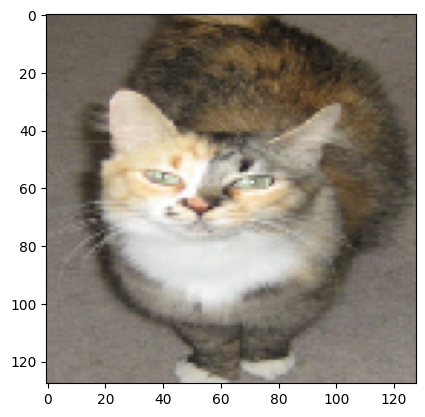

推定： cat
正解： cat
------------------------------------------------------------



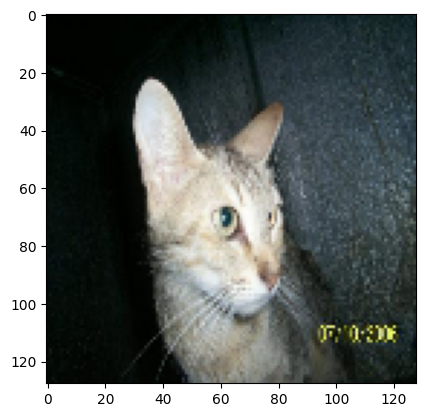

推定： cat
正解： cat
------------------------------------------------------------



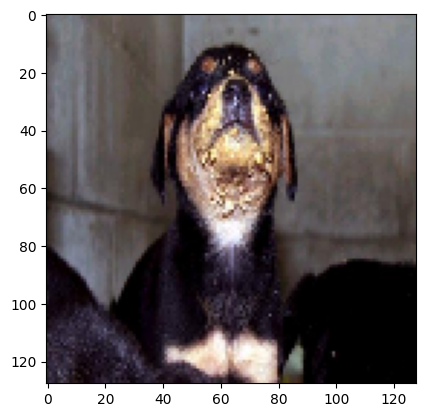

推定： dog
正解： dog
------------------------------------------------------------



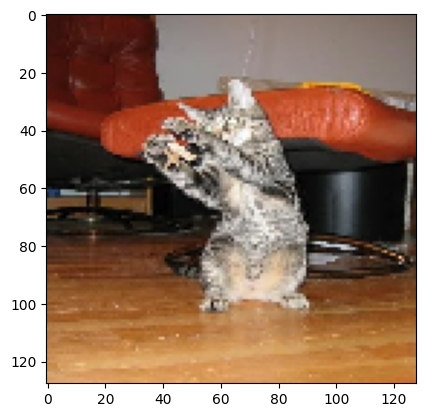

推定： cat
正解： cat
------------------------------------------------------------



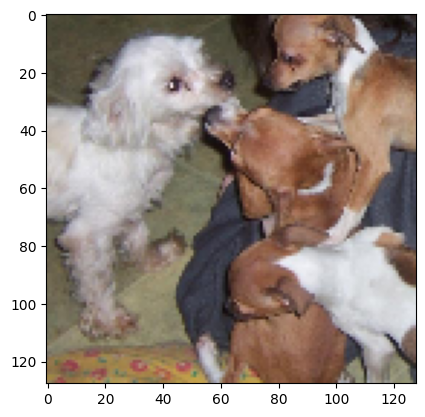

推定： dog
正解： dog
------------------------------------------------------------



In [ ]:
code_to_class = {0: 'cat', 1: 'dog'}

# 1バッチ分を取得
for images, labels in train_dataset.take(1):

    y_true = np.argmax( labels, axis = 1 )
    y_prob = model.predict_on_batch( images )
    y_pred = np.argmax( y_prob, axis = 1 )

    #しかし，今回はバッチサイズが128と
    # プロットするには多いので
    print(images.shape)
    print(labels.shape)

    # 先頭の5枚のみプロットします．
    for i in range(5):
        plt.imshow(images[i])
        plt.show()
        print('推定：', code_to_class[y_pred[i]])
        print('正解：', code_to_class[y_true[i]])
        print(''.join(['-' for _ in range(60)]), end = '\n\n')

### tensorboard による可視化

このコードを実行するときは，Colabを開いているブラウザでサードパーティ製のクッキーを許可してください．（もしブロックしていると，403エラーが表示されます．）

In [ ]:
%tensorboard --logdir logs_cnn/fit